### Importing Libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
np.random.seed(42)
import matplotlib.pyplot as plt

### Reading House Data

In [3]:
df = pd.read_excel("./Datasets/Real_estate_valuation.xlsx")

In [4]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [5]:
df = df.rename(columns={"X1 transaction date" : "transaction_date",
                        "X2 house age":"house_age",
                        "X3 distance to the nearest MRT station": "distance_to_mrt_station",
                        "X4 number of convenience stores": "no_of_convenience_stores",
                        "X5 latitude" : "latitude",
                        "X6 longitude" : "longitude",
                        "Y house price of unit area" : "Y_house_price_unit_area"})
df.head()

,No,transaction_date,house_age,distance_to_mrt_station,no_of_convenience_stores,latitude,longitude,Y_house_price_unit_area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [6]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   No                        414 non-null    int64  
 1   transaction_date          414 non-null    float64
 2   house_age                 414 non-null    float64
 3   distance_to_mrt_station   414 non-null    float64
 4   no_of_convenience_stores  414 non-null    int64  
 5   latitude                  414 non-null    float64
 6   longitude                 414 non-null    float64
 7   Y_house_price_unit_area   414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


### Splitting dependent and independent variable

In [7]:
X = df.drop("Y_house_price_unit_area", axis=1).to_numpy()  ###axis 1 column wise
Y = df["Y_house_price_unit_area"].to_numpy()

### Standardization  Normalizing our data

In [8]:
X_mean = np.mean(X,axis  = 0, keepdims=True)
X_std = np.std(X,axis = 0,keepdims=True)

Y_mean = np.mean(Y)
Y_std = np.std(Y)

X_norm = (X -X_mean)/X_std
Y_norm =  (Y - Y_mean)/Y_std
Y_norm = Y_norm.reshape(-1,1)


### Intializing random Parameters

In [13]:
def intializing_params(X):
    W = np.random.randn(X.shape[1],1)
    b = 0
    return W, b
W,b = intializing_params(X)

### Def loss function MSE

In [14]:
def compute_loss(Y,Y_hat):
    n  = Y.shape[0]
    return np.sum((Y_hat - Y)**2)/(2*n)

### Predict Function


In [15]:
def predict(W,b,X):
    return X @ W +b

### Optimizer Gradient Descent

In [16]:
def dEdw(X,Y,W,b):
    n = Y.shape[0]

    Y_hat = predict(W,b,X)
    residual = Y_hat - Y

    rv = np.dot(residual.T, X) / n
    return rv.T
def dEdb(X,Y,W,b):
    n = Y.shape[0]
    Y_hat = predict(W,b,X)
    return np.sum((Y_hat - Y)) / n


### Train Function



In [17]:
def train(X_norm,Y_norm,W,b,learning_rate = 0.2, epochs = 200):
    losses = []
    for i in range(epochs):
        dw = dEdw(X_norm,Y_norm,W,b)

        db = dEdb(X_norm,Y_norm,W,b)

        W -= learning_rate * dw
        b -= learning_rate * db

        Y_hat = predict(W,b,X_norm)
        losses.append(compute_loss(Y_norm,Y_hat))

        print(f"Loss after iteration {i}: {losses[-1]}")
    return W,b

W,b  = train(X_norm, Y_norm, W, b)

Loss after iteration 0: 1.2806960618691423
Loss after iteration 1: 0.9883062550976435
Loss after iteration 2: 0.8325256221448779
Loss after iteration 3: 0.7292989615060048
Loss after iteration 4: 0.6537035967453774
Loss after iteration 5: 0.5957311253469721
Loss after iteration 6: 0.5500249155103968
Loss after iteration 7: 0.513198503949083
Loss after iteration 8: 0.48294825969094757
Loss after iteration 9: 0.45765575730192015
Loss after iteration 10: 0.43616320810050785
Loss after iteration 11: 0.4176308951474823
Loss after iteration 12: 0.4014420953590065
Loss after iteration 13: 0.3871382478250521
Loss after iteration 14: 0.3743741641269642
Loss after iteration 15: 0.3628867631340105
Loss after iteration 16: 0.3524730351623516
Loss after iteration 17: 0.3429743629525413
Loss after iteration 18: 0.33426526005874396
Loss after iteration 19: 0.32624520657364636
Loss after iteration 20: 0.31883267640319446
Loss after iteration 21: 0.31196072937483166
Loss after iteration 22: 0.305573730

In [18]:
Y_hat = predict(W,b,X_norm)

### Denormalization

In [19]:
Y_hat_org = Y_hat * Y_std + Y_mean
pd.DataFrame({
    "Y_orignal" : Y.ravel(),
    "Y_predicted" : Y_hat_org.ravel()

})

,Y_orignal,Y_predicted
0,37.9,47.903133
1,42.2,48.572867
2,47.3,49.510107
3,54.8,49.083810
4,43.1,46.905335
...,...,...
409,15.4,13.670755
410,50.0,49.174414
411,40.6,46.086638
412,52.5,43.899136


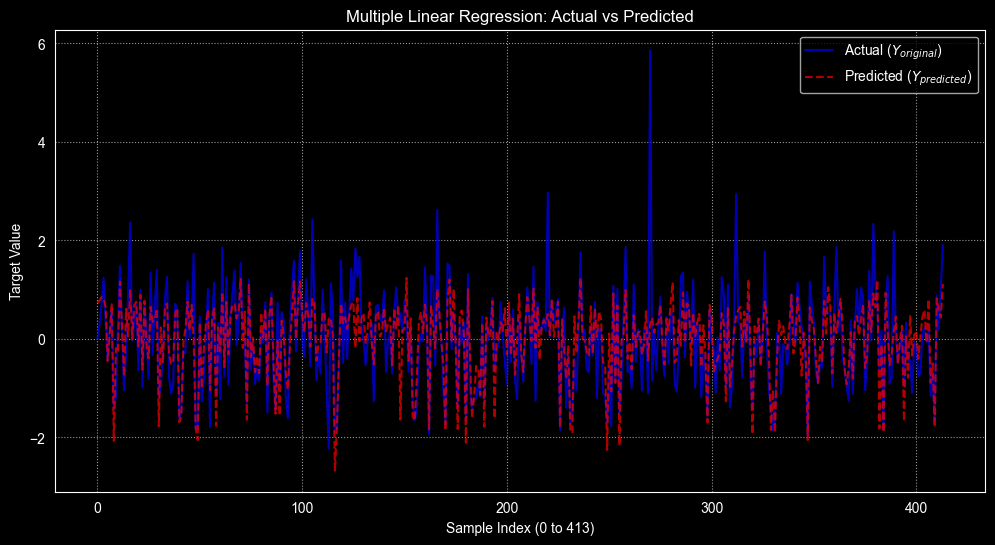

In [20]:
import matplotlib.pyplot as plt

# Generate predictions from your trained multiple regression model
Y_pred = predict(W, b, X_norm)

plt.figure(figsize=(12, 6))
plt.plot(Y_norm, label='Actual ($Y_{original}$)', color='blue', alpha=0.7)
plt.plot(Y_pred, label='Predicted ($Y_{predicted}$)', color='red', linestyle='--', alpha=0.7)

plt.xlabel('Sample Index (0 to 413)')
plt.ylabel('Target Value')
plt.title('Multiple Linear Regression: Actual vs Predicted')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### We will Apply Linear regression then on it Poynomial Regression Cuz it is easy to visualize

In [21]:
df.head()

,No,transaction_date,house_age,distance_to_mrt_station,no_of_convenience_stores,latitude,longitude,Y_house_price_unit_area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


### Splitting Target and input Variables

In [22]:
X = df["house_age"].to_numpy().reshape(-1,1)
Y = df["Y_house_price_unit_area"].to_numpy().reshape(-1,1)
X_norm = (X - np.mean(X))/np.std(X)
Y_norm = (Y - np.mean(Y))/np.std(Y)


### initializing random weights

In [23]:
W, b  = intializing_params(X)
W

array([[0.76743473]])

### Training

In [24]:
W, b = train(X_norm,Y_norm, W, b,learning_rate = 0.1, epochs = 2000)

Loss after iteration 0: 0.8652081859725577
Loss after iteration 1: 0.7916064749448701
Loss after iteration 2: 0.7319890890124433
Loss after iteration 3: 0.6836990064071774
Loss after iteration 4: 0.644584039496912
Loss after iteration 5: 0.6129009162995972
Loss after iteration 6: 0.5872375865097721
Loss after iteration 7: 0.5664502893800137
Loss after iteration 8: 0.5496125787049095
Loss after iteration 9: 0.5359740330580751
Loss after iteration 10: 0.5249268110841392
Loss after iteration 11: 0.5159785612852512
Loss after iteration 12: 0.5087304789481519
Loss after iteration 13: 0.5028595322551014
Loss after iteration 14: 0.4981040654337305
Loss after iteration 15: 0.4942521373084201
Loss after iteration 16: 0.49113207552691873
Loss after iteration 17: 0.4886048254839025
Loss after iteration 18: 0.48655775294905945
Loss after iteration 19: 0.4848996241958366
Loss after iteration 20: 0.483556539905726
Loss after iteration 21: 0.4824686416307365
Loss after iteration 22: 0.481587444027994

In [25]:
Y_hat = predict(W,b,X_norm)
Y_pred = Y_hat * np.std(Y) + np.mean(Y)

pd.DataFrame({
    "Original" : Y.ravel(),
    "Predicted" : Y_pred.ravel()
})

,Original,Predicted
0,37.9,34.387068
1,42.2,37.530673
2,47.3,39.089901
3,54.8,39.089901
4,43.1,41.177255
...,...,...
409,15.4,38.989306
410,50.0,41.026362
411,40.6,37.706715
412,52.5,40.397641


### Plotting Regression line

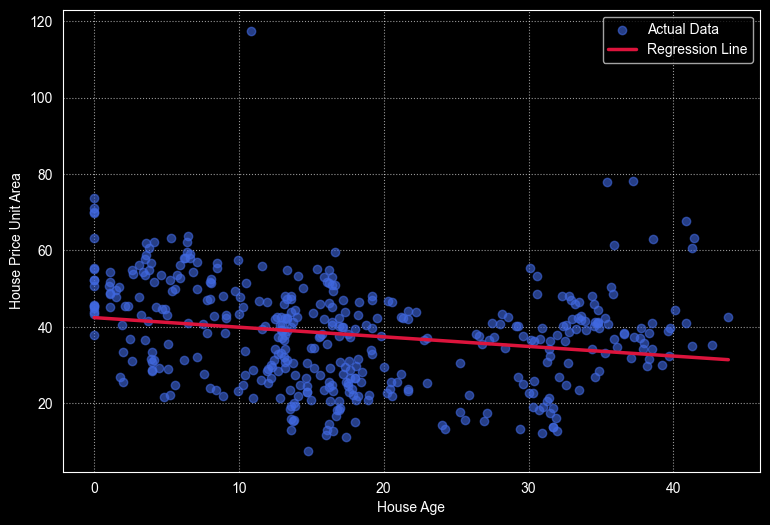

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Sort X and Y_hat by the X values so the line draws smoothly from left to right
sort_idx = np.argsort(X.flatten())
X_sorted = X[sort_idx]
Y_hat_sorted = Y_pred[sort_idx]

# 2. Draw the scatter plot and the straight regression line
plt.figure(figsize=(9, 6))
plt.scatter(X, Y, color='royalblue', alpha=0.6, label='Actual Data')
plt.plot(X_sorted, Y_hat_sorted, color='crimson', linewidth=2.5, label='Regression Line')

plt.xlabel('House Age')
plt.ylabel('House Price Unit Area')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Function To Create Polynomial Features And initialize Weights acc to degree

In [27]:
def create_polynomial_features(X,degree=2):
    n_col = X.shape[1]
    for i in range(n_col):
        x = X[:,i]
        columns = [X]
        poly = x.copy().reshape(-1,1)

        for j in range(2,degree+1):
            columns.append(poly**j)
    return np.column_stack(columns)
poly_features = create_polynomial_features(X,degree=3)
print(poly_features[:5])
W, b =   intializing_params(poly_features)
W.shape


[[3.200000e+01 1.024000e+03 3.276800e+04]
 [1.950000e+01 3.802500e+02 7.414875e+03]
 [1.330000e+01 1.768900e+02 2.352637e+03]
 [1.330000e+01 1.768900e+02 2.352637e+03]
 [5.000000e+00 2.500000e+01 1.250000e+02]]


(3, 1)

### Normalizing Polynomial Features

In [28]:

X_pol_mean = np.mean(poly_features, axis = 0, keepdims = True)
X_pol_std = np.std(poly_features, axis = 0, keepdims = True)
Y_mean = np.mean(Y)
Y_std = np.std(Y)

X_pol_norm = (poly_features - X_pol_mean) / X_pol_std
Y_norm = (Y - Y_mean) / Y_std

In [29]:
W,b = train(X_pol_norm,Y_norm,W,b,learning_rate = 0.01, epochs = 1000)

Loss after iteration 0: 0.508396267493681
Loss after iteration 1: 0.506457710115207
Loss after iteration 2: 0.5046220496702064
Loss after iteration 3: 0.5028834082184898
Loss after iteration 4: 0.5012362444265704
Loss after iteration 5: 0.4996753342899677
Loss after iteration 6: 0.49819575295955776
Loss after iteration 7: 0.49679285760874586
Loss after iteration 8: 0.4954622712818494
Loss after iteration 9: 0.4941998676674975
Loss after iteration 10: 0.4930017567440716
Loss after iteration 11: 0.4918642712472425
Loss after iteration 12: 0.49078395391252366
Loss after iteration 13: 0.4897575454484541
Loss after iteration 14: 0.4887819731985668
Loss after iteration 15: 0.4878543404526959
Loss after iteration 16: 0.4869719163704343
Loss after iteration 17: 0.486132126481683
Loss after iteration 18: 0.48533254373124246
Loss after iteration 19: 0.48457088003628657
Loss after iteration 20: 0.48384497832734863
Loss after iteration 21: 0.4831528050451253
Loss after iteration 22: 0.482492443066

In [30]:
Y_pred = predict(W,b,X_pol_norm)
Y_pred_orignal = Y_pred * Y_std + Y_mean

pd.DataFrame({
    "Orignal" : Y.ravel(),
    "Predicted" : Y_pred_orignal.ravel()
})

,Orignal,Predicted
0,37.9,35.184906
1,42.2,34.026763
2,47.3,36.593469
3,54.8,36.593469
4,43.1,42.976156
...,...,...
409,15.4,36.369123
410,50.0,42.407848
411,40.6,34.217156
412,52.5,40.215342


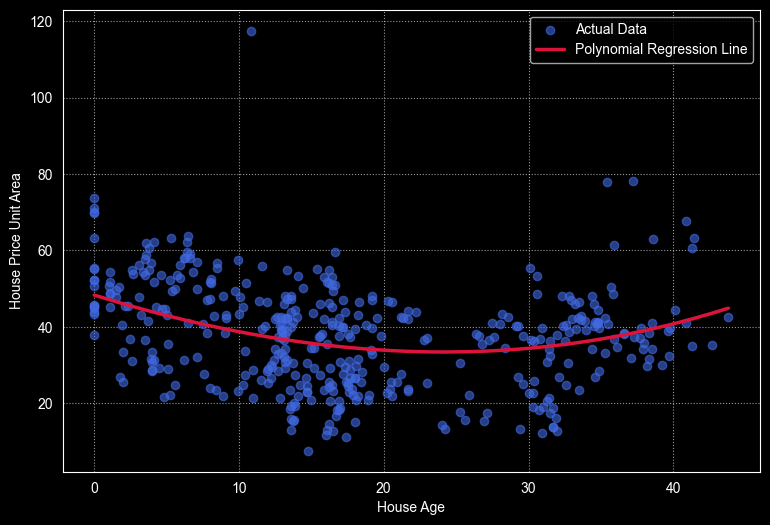

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Sort X and Y_hat by the X values so the line draws smoothly from left to right
sort_idx = np.argsort(X.flatten())
X_sorted = X[sort_idx]
Y_hat_sorted = Y_pred_orignal[sort_idx]

# 2. Draw the scatter plot and the straight regression line
plt.figure(figsize=(9, 6))
plt.scatter(X, Y, color='royalblue', alpha=0.6, label='Actual Data')
plt.plot(X_sorted, Y_hat_sorted, color='crimson', linewidth=2.5, label='Polynomial Regression Line')

plt.xlabel('House Age')
plt.ylabel('House Price Unit Area')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Applying Polynomial Regression on Multiple Features

In [32]:
X = df.drop("Y_house_price_unit_area",axis = 1).to_numpy()
Y = df["Y_house_price_unit_area"].to_numpy().reshape(-1,1)




### Creating Polynomial Features

In [33]:
poly_features = create_polynomial_features(X,degree=4)
print(poly_features[:1])
print(poly_features.shape)
W, b =   intializing_params(poly_features)
W.shape

[[1.00000000e+00 2.01291667e+03 3.20000000e+01 8.48788200e+01
  1.00000000e+01 2.49829800e+01 1.21540240e+02 1.47720299e+04
  1.79539606e+06 2.18212869e+08]]
(414, 10)


(10, 1)

### Normalizing Features To avoid overflow in GD

In [34]:
X_pol_mean = np.mean(poly_features,axis = 0, keepdims=True)
X_pol_std = np.std(poly_features,axis = 0, keepdims=True)
Y_mean = np.mean(Y,keepdims=True)
Y_std = np.std(Y, keepdims=True)

X_pol_norm = (poly_features - X_pol_mean)/X_pol_std
Y_pol_norm = (Y - Y_mean)/Y_std
X_pol_norm.shape

(414, 10)

### Training

In [35]:
W,b = train(X_pol_norm, Y_pol_norm, W, b,learning_rate=0.01,epochs = 1000)

Loss after iteration 0: 2.631280128544195
Loss after iteration 1: 2.577517325375097
Loss after iteration 2: 2.5256178687646624
Loss after iteration 3: 2.475466805381614
Loss after iteration 4: 2.426959337962928
Loss after iteration 5: 2.379999819522608
Loss after iteration 6: 2.334500849876514
Loss after iteration 7: 2.2903824640142765
Loss after iteration 8: 2.24757140292188
Loss after iteration 9: 2.2060004584210673
Loss after iteration 10: 2.165607884455687
Loss after iteration 11: 2.1263368680305432
Loss after iteration 12: 2.088135053704279
Loss after iteration 13: 2.050954116162469
Loss after iteration 14: 2.014749375957748
Loss after iteration 15: 1.979479454007014
Loss after iteration 16: 1.945105960887349
Loss after iteration 17: 1.9115932173776986
Loss after iteration 18: 1.878908003057142
Loss after iteration 19: 1.8470193300971498
Loss after iteration 20: 1.8158982396783079
Loss after iteration 21: 1.785517618725037
Loss after iteration 22: 1.7558520348879494
Loss after ite

In [36]:
Y_pred = predict(W,b,X_pol_norm)
Y_pred_orignal = Y_pred * Y_std + Y_mean

pd.DataFrame({
    "Orignal" : Y.ravel(),
    "Predicted" : Y_pred_orignal.ravel()

})

,Orignal,Predicted
0,37.9,47.013017
1,42.2,47.584996
2,47.3,48.282807
3,54.8,47.800513
4,43.1,46.344461
...,...,...
409,15.4,12.656166
410,50.0,48.157134
411,40.6,45.384701
412,52.5,45.071622


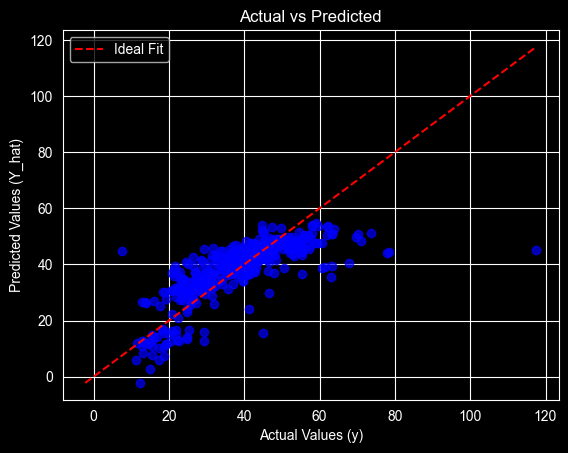

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Both y and Y_hat_original must have shape (m,)
plt.scatter(Y, Y_pred_orignal, c="b", alpha=0.7)

# Draw a reference ideal line (y = x)
min_val = min(np.min(Y), np.min(Y_pred_orignal))
max_val = max(np.max(Y), np.max(Y_pred_orignal))
plt.plot([min_val, max_val], [min_val, max_val], c="r", linestyle="--", label="Ideal Fit")

plt.xlabel("Actual Values (y)")
plt.ylabel("Predicted Values (Y_hat)")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()